# Cross-Validation: A Comprehensive Guide

Cross-Validation is a model evaluation technique that estimates how well a model will generalize to unseen data by testing it on multiple different splits of the training data. It helps detect overfitting and provides a more reliable estimate of model performance than a single train/test split.

In this notebook, we'll cover:
1. Basic concepts of Cross-Validation
2. Types: K-Fold, Stratified K-Fold, Leave-One-Out, Time Series Split
3. Implementing K-Fold from scratch
4. Using scikit-learn for cross-validation
5. Model selection and hyperparameter tuning with CV

# Simple Explanation: What Does the Code Below Do?

Imagine you're studying for an exam. If you only practice on the same 10 questions over and over, you might memorize the answers without truly learning the subject. Cross-validation ensures your model is truly learning, not just memorizing!

**K-Fold Cross-Validation**:
1. Split data into K equal 'folds'.
2. Train on K-1 folds, evaluate on the remaining fold.
3. Repeat K times, each time using a different fold for evaluation.
4. Average the K scores → reliable performance estimate.

Why is it better than a single split?
- Uses ALL data for both training and testing (just at different times).
- Gives K performance estimates → you can see the variance.
- Reduces the impact of lucky/unlucky data splits.

Here's what the code does:
1. Implements K-Fold cross-validation from scratch.
2. Demonstrates different CV strategies (K-Fold, Stratified, LOO).
3. Uses CV for model selection and hyperparameter tuning.

In short: Cross-validation ensures your model's performance is reliable, not just a lucky fluke!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import (KFold, StratifiedKFold, LeaveOneOut, 
                                     cross_val_score, cross_validate, 
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Understanding the Problem: Why Not Just Use One Split?

Single split scores (20 different random seeds):
  Mean: 0.9583
  Std:  0.0407
  Min:  0.8667
  Max:  1.0000
  Range:0.1333

5-Fold CV scores: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
  Mean: 0.9600 ± 0.0249


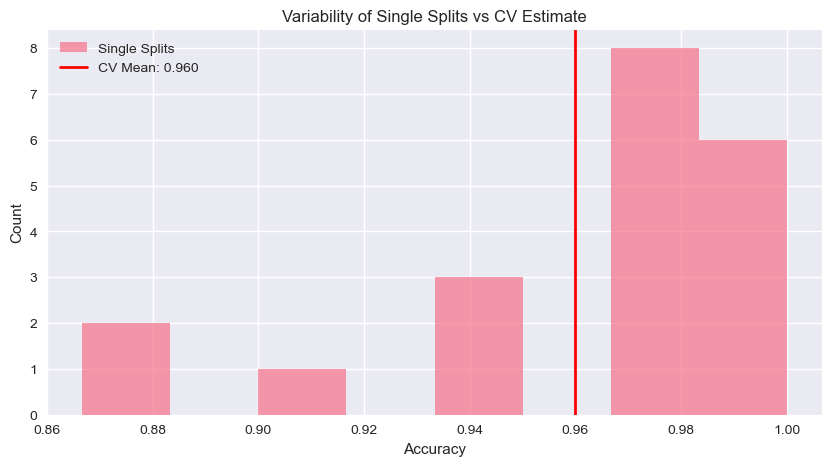

In [3]:
iris = load_iris()
X, y = iris.data, iris.target

from sklearn.model_selection import train_test_split

# Show variance from different random splits
single_split_scores = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_tr, y_tr)
    single_split_scores.append(accuracy_score(y_te, rf.predict(X_te)))

print('Single split scores (20 different random seeds):')
print(f'  Mean: {np.mean(single_split_scores):.4f}')
print(f'  Std:  {np.std(single_split_scores):.4f}')
print(f'  Min:  {min(single_split_scores):.4f}')
print(f'  Max:  {max(single_split_scores):.4f}')
print(f'  Range:{max(single_split_scores) - min(single_split_scores):.4f}')

# Compare with 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=50, random_state=42), 
                             X, y, cv=kf, scoring='accuracy')
print(f'\n5-Fold CV scores: {cv_scores}')
print(f'  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(single_split_scores, bins=8, alpha=0.7, label='Single Splits')
plt.axvline(cv_scores.mean(), color='red', linewidth=2, label=f'CV Mean: {cv_scores.mean():.3f}')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.title('Variability of Single Splits vs CV Estimate')
plt.legend()
plt.grid(True)
plt.show()

# 3. Implementing K-Fold CV from Scratch

In [4]:
class KFoldScratch:
    def __init__(self, n_splits=5, shuffle=True, random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X):
        n = len(X)
        indices = np.arange(n)
        if self.shuffle:
            rng = np.random.RandomState(self.random_state)
            rng.shuffle(indices)

        fold_sizes = np.full(self.n_splits, n // self.n_splits)
        fold_sizes[:n % self.n_splits] += 1  # distribute remainder

        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            test_idx = indices[start:stop]
            train_idx = np.concatenate([indices[:start], indices[stop:]])
            yield train_idx, test_idx
            current = stop

# Use our scratch KFold
kf_scratch = KFoldScratch(n_splits=5, random_state=42)
scores_scratch = []

for fold, (train_idx, test_idx) in enumerate(kf_scratch.split(X)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    model = RandomForestClassifier(n_estimators=50, random_state=42)
    model.fit(X_tr, y_tr)
    score = accuracy_score(y_te, model.predict(X_te))
    scores_scratch.append(score)
    print(f'Fold {fold+1}: Train size={len(train_idx)}, Test size={len(test_idx)}, Accuracy={score:.4f}')

print(f'\nMean CV Accuracy: {np.mean(scores_scratch):.4f} ± {np.std(scores_scratch):.4f}')

Fold 1: Train size=120, Test size=30, Accuracy=1.0000
Fold 2: Train size=120, Test size=30, Accuracy=0.9667
Fold 3: Train size=120, Test size=30, Accuracy=0.9333
Fold 4: Train size=120, Test size=30, Accuracy=0.9333
Fold 5: Train size=120, Test size=30, Accuracy=0.9667

Mean CV Accuracy: 0.9600 ± 0.0249


# 4. Different CV Strategies and Model Selection

In [5]:
# Compare different CV strategies
strategies = {
    'K-Fold (K=5)': KFold(n_splits=5, shuffle=True, random_state=42),
    'Stratified K-Fold (K=5)': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'K-Fold (K=10)': KFold(n_splits=10, shuffle=True, random_state=42),
}

print('Comparing CV Strategies on Iris dataset:')
for name, cv in strategies.items():
    scores = cross_val_score(RandomForestClassifier(n_estimators=50, random_state=42), 
                              X, y, cv=cv, scoring='accuracy')
    print(f'  {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}')

# Model Selection with CV
print('\nModel Selection with Cross-Validation:')
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', random_state=42))]),
}

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'  {name:<20}: {scores.mean():.4f} ± {scores.std():.4f}')

Comparing CV Strategies on Iris dataset:
  K-Fold (K=5)             : 0.9600 ± 0.0249
  Stratified K-Fold (K=5)  : 0.9533 ± 0.0340
  K-Fold (K=10)            : 0.9600 ± 0.0533

Model Selection with Cross-Validation:
  Decision Tree       : 0.9533 ± 0.0340
  Random Forest       : 0.9467 ± 0.0267
  SVM (RBF)           : 0.9600 ± 0.0389


# 5. Hyperparameter Tuning with GridSearchCV

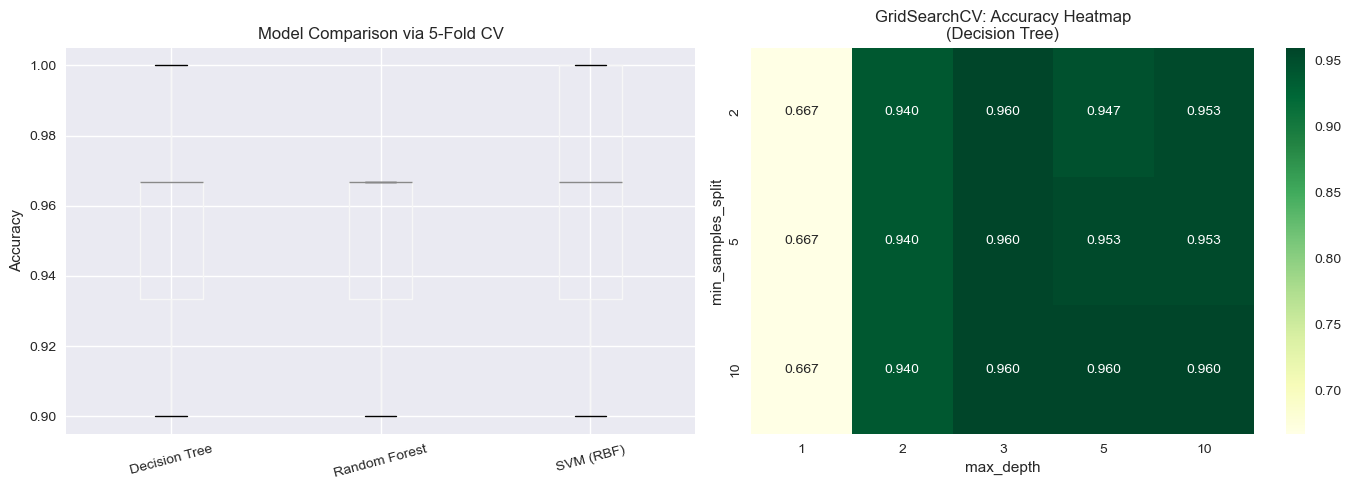

Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.9600

Key Insights:
- Use Stratified K-Fold for imbalanced classification problems.
- K=5 or K=10 is a good default choice.
- Nested CV: Outer CV for evaluation, Inner CV for hyperparameter tuning.
- Never tune hyperparameters on the test set!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Model Comparison Boxplot
cv_data = pd.DataFrame(cv_results)
cv_data.boxplot(ax=axes[0])
axes[0].set_title('Model Comparison via 5-Fold CV')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y')

# 2. GridSearchCV example
param_grid = {'max_depth': [1, 2, 3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, 
                            cv=skf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Heatmap of CV results
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(values='mean_test_score',
                                 index='param_min_samples_split', 
                                 columns='param_max_depth')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=axes[1])
axes[1].set_title('GridSearchCV: Accuracy Heatmap\n(Decision Tree)')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('min_samples_split')

plt.tight_layout()
plt.show()

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')
print('\nKey Insights:')
print('- Use Stratified K-Fold for imbalanced classification problems.')
print('- K=5 or K=10 is a good default choice.')
print('- Nested CV: Outer CV for evaluation, Inner CV for hyperparameter tuning.')
print('- Never tune hyperparameters on the test set!')

# Conclusions and Key Takeaways
Cross-validation is a crucial resampling procedure used to evaluate machine learning models on a limited data sample. It provides a more accurate estimate of out-of-sample accuracy than single train-test splits.
- Helps prevent overfitting by ensuring the model performs consistently across different subsets of data.
- k-fold Cross-Validation is the standard approach, usually with k=5 or k=10.
- Stratified cross-validation is essential for dealing with imbalanced datasets.

# Pros and Cons
**Pros:**
- Provides a more robust estimate of model performance on unseen data.
- Maximizes the use of available data (every observation is used for both training and validation).
- Helps fine-tune hyperparameters more reliably.

**Cons:**
- Computationally expensive, as the model needs to be trained 'k' times.
- Can be tricky to implement properly with sequential data (like time series) without leaking future information.

# 15 Interview Questions and Answers

1. **What is cross-validation?**
   *Answer*: It is a statistical method used to estimate the skill of machine learning models. It involves partitioning the data into subsets, training the model on some subsets, and evaluating it on the remaining subset.

2. **Why do we use cross-validation instead of a simple train/test split?**
   *Answer*: A single train/test split can be lucky or unlucky depending on how the data is partitioned. Cross-validation averages the performance across multiple splits, providing a more stable and reliable estimate.

3. **What is k-fold cross-validation?**
   *Answer*: The data is divided into 'k' equal-sized folds. The model is trained on k-1 folds and validated on the remaining 1 fold. This process is repeated k times, with each fold acting as the validation set exactly once.

4. **How do you choose the value of 'k'?**
   *Answer*: Usually, k=5 or k=10 are chosen as they have been empirically shown to yield test error rate estimates that suffer neither from excessively high bias nor from very high variance.

5. **What is Leave-One-Out Cross-Validation (LOOCV)?**
   *Answer*: It is a case of k-fold cross-validation where k equals the total number of observations in the dataset. Only one sample is used as the validation set in each iteration.

6. **When would you use LOOCV?**
   *Answer*: When the dataset is extremely small, and you want to maximize the data used for training in every fold.

7. **What is the main drawback of LOOCV?**
   *Answer*: It is highly computationally expensive since the model must be trained 'n' times (where n is the dataset size). Also, it can have high variance in the error estimate.

8. **What is Stratified k-fold Cross-Validation?**
   *Answer*: It is a variation of k-fold CV that returns stratified folds. Each set contains approximately the same percentage of samples of each target class as the complete set. 

9. **Why is Stratified CV important?**
   *Answer*: It ensures that even in highly imbalanced datasets, every fold has an appropriate representation of the minority class, preventing the model from encountering a fold with only one class.

10. **Can you use regular k-fold CV for time-series data?**
    *Answer*: No, because time-series data has a chronological order. Standard CV would randomly shuffle data, leading to "data leakage" (training on future data to predict the past). Instead, Time Series Split (Walk-Forward Validation) must be used.

11. **How does Nested Cross-Validation work?**
    *Answer*: It involves an outer loop for estimating model generalization performance and an inner loop for hyperparameter tuning. This prevents data leakage during hyperparameter selection.

12. **Is cross-validation typically used in Deep Learning?**
    *Answer*: Not always. Deep learning models often require massive datasets and long training times. Splitting the data once (Train/Val/Test) is often statistically sufficient and computationally feasible, unlike 'k' trainings.

13. **What happens if you do feature selection before cross-validation?**
    *Answer*: This causes data leakage. Feature selection evaluates the correlation between features and the target variable. Doing this on the entire dataset means the validation folds have already "seen" the target variables during training, leading to overly optimistic results.

14. **How does Group k-fold CV work?**
    *Answer*: It ensures that the same "group" (e.g., patient ID, specific user) is not split across both the training and validation sets, preventing the model from recognizing specific entities rather than generalizing.

15. **What is the difference between validation set and test set?**
    *Answer*: The validation set is used during training to tune hyperparameters and make decisions about model structure. The test set is only used once, at the very end, to provide an unbiased evaluation of the final model's performance.
